In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import gc
from my_functions import *
sns.set_theme()
gc.enable()

In [3]:
main_data=pd.read_csv('application_train.csv')
main_data.shape

(307511, 122)

Text(0.5, 0, 'Fig 1. Distribution of TARGET feature')

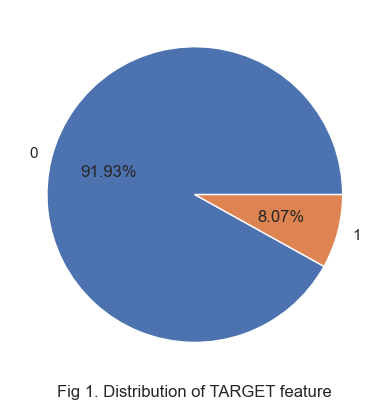

In [4]:
main_data.TARGET.value_counts().plot.pie(autopct='%1.2f%%')
ax=plt.gca()
ax.set_ylabel('')
ax.set_xlabel('Fig 1. Distribution of TARGET feature')

Text(0.5, 1.0, ' Fig 2. Features with the Highest PCT of Null Values')

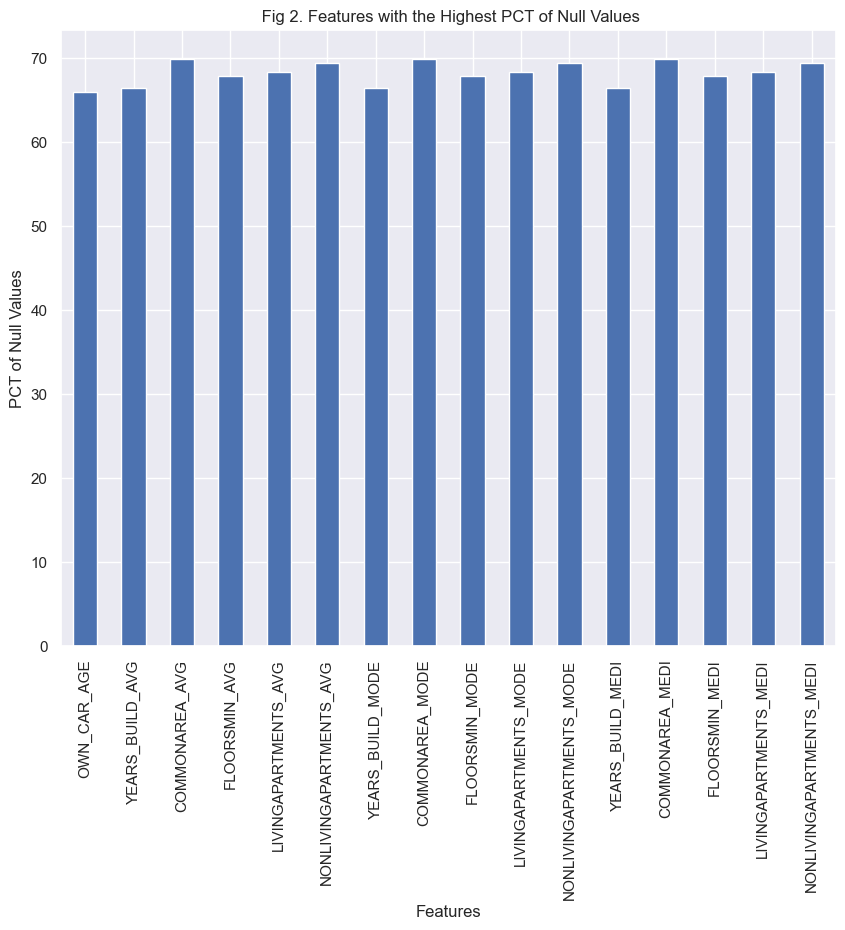

In [5]:
numerical_features=main_data.select_dtypes(exclude='object').columns
numerical_frame=main_data[numerical_features]
temp=numerical_frame.isnull().sum()*100/numerical_frame.shape[0]
temp[temp.between(60, 100)].plot.bar()
ax=plt.gca()
fig=plt.gcf()
fig.set_size_inches(10, 8)
ax.set_ylabel('PCT of Null Values')
ax.set_xlabel('Features')
ax.set_title(' Fig 2. Features with the Highest PCT of Null Values')

In [6]:
temp[temp.between(60, 100)].to_frame().reset_index().rename(columns={'index':'Feature', 0: 'PCT of Null Values'})

,Feature,PCT of Null Values
0,OWN_CAR_AGE,65.990810
1,YEARS_BUILD_AVG,66.497784
2,COMMONAREA_AVG,69.872297
3,FLOORSMIN_AVG,67.848630
4,LIVINGAPARTMENTS_AVG,68.354953
5,NONLIVINGAPARTMENTS_AVG,69.432963
6,YEARS_BUILD_MODE,66.497784
7,COMMONAREA_MODE,69.872297
8,FLOORSMIN_MODE,67.848630
9,LIVINGAPARTMENTS_MODE,68.354953


In [7]:
important_kde=pd.Index(['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE', 'DAYS_BIRTH',
                        'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION',
                        'DAYS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
                        'EXT_SOURCE_3'])
numerical_frame=main_data[important_kde]
numerical_frame['TARGET']=main_data['TARGET']
numerical_frame['SK_ID_CURR']=main_data['SK_ID_CURR']

C:\Users\hp\AppData\Local\Temp\ipykernel_12520\3174998301.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numerical_frame['TARGET']=main_data['TARGET']
C:\Users\hp\AppData\Local\Temp\ipykernel_12520\3174998301.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numerical_frame['SK_ID_CURR']=main_data['SK_ID_CURR']


EXT_SOURCE_1_binned
(0.013600000000000001, 0.223]    16.968599
(0.223, 0.313]                   11.225174
(0.313, 0.392]                    9.078709
(0.392, 0.468]                    7.440955
(0.468, 0.544]                    6.401396
(0.544, 0.618]                    5.414654
(0.618, 0.694]                    4.737301
(0.694, 0.777]                    3.502415
(0.777, 0.963]                    2.690553
Name: count, dtype: float64


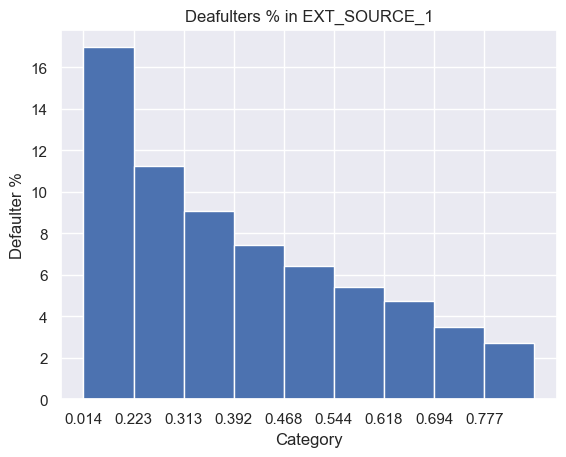

In [8]:
plot_hist_default_pct('EXT_SOURCE_1', numerical_frame, 9)

<Axes: >

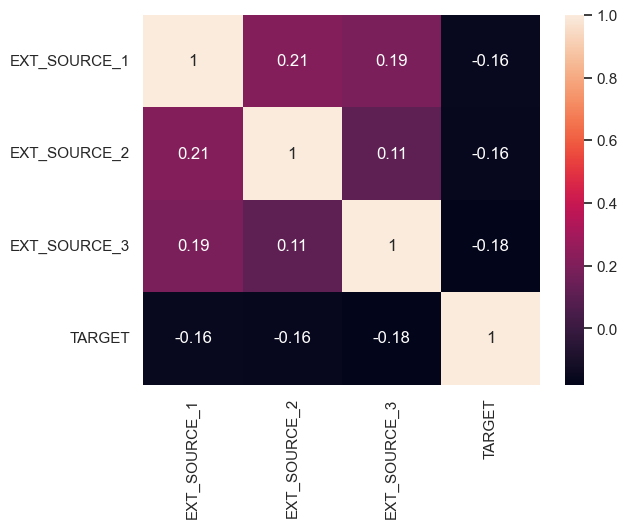

In [13]:
sns.heatmap(numerical_frame[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']].corr(), annot=True)

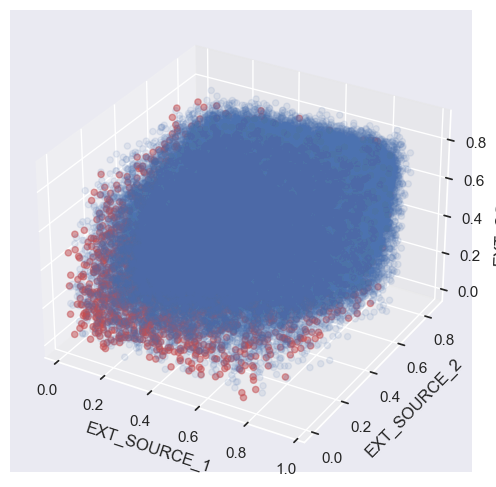

In [30]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# ax.scatter(numerical_frame['EXT_SOURCE_1'], numerical_frame['EXT_SOURCE_2'], 
        #    numerical_frame['EXT_SOURCE_3'], marker=numerical_frame['TARGET'])
color=np.array(['r']*numerical_frame.shape[0])
color[numerical_frame['TARGET']==0]='b'
sub_1=numerical_frame[numerical_frame['TARGET']==0]
sub_2=numerical_frame[numerical_frame['TARGET']==1]

ax.scatter(xs=sub_1['EXT_SOURCE_1'], ys=sub_1['EXT_SOURCE_2'], 
           zs=sub_1['EXT_SOURCE_3'], c='b', alpha=0.1)
ax.scatter(xs=sub_2['EXT_SOURCE_1'], ys=sub_2['EXT_SOURCE_2'], 
           zs=sub_2['EXT_SOURCE_3'], c='r', alpha=0.5)
ax.set_xlabel('EXT_SOURCE_1')
ax.set_ylabel('EXT_SOURCE_2')
ax.set_zlabel('EXT_SOURCE_3')
fig.set_size_inches(9, 6)